In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
from tqdm.notebook import tqdm
import seaborn as sns

from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from ibl_info.utils import generate_source_ids
from glob import glob

from ibl_info.rsi_collating import (
    collate_pairwise_comparisons,
    collate_pairwise_comparisons_choice,
    plot_counts,
    convert_pairs_into_arrays,
    rsi_plots,
    plot_region_wise_tvmi,
)
from iblatlas.plots import plot_swanson_vector
from iblatlas.atlas import BrainRegions

br = BrainRegions()

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
colors = ["#A6CEE3", "#FDBF6F"]

In [133]:
files_stim = np.sort(glob("../data/generated/mifiltered/3bins/*.pkl"))
pairwise_stim = collate_pairwise_comparisons(files_stim)
del pairwise_stim["MG"]
final_dict_stim = convert_pairs_into_arrays(pairwise_stim)

In [134]:
# rsi_plots(final_dict_stim, "Stimulus")
# plt.savefig("../reports/rsi_stimulus_equi.png", bbox_inches="tight", facecolor="white", dpi=300)

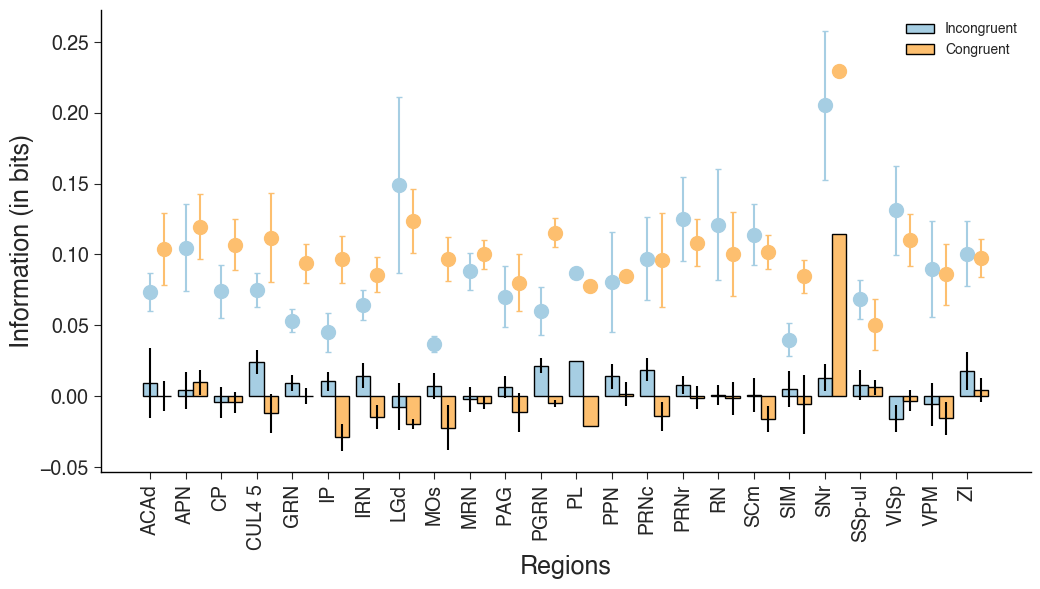

In [136]:
plt.style.use("../figures.style")
plot_region_wise_tvmi(final_dict=final_dict_stim)

In [97]:
# plot_counts(final_dict=final_dict_choice)

In [9]:
files_choice = np.sort(glob("../data/generated/choice/pseudo/equi/*.pkl"))
pairwise_choice = collate_pairwise_comparisons_choice(files_choice)
# del pairwise_choice["MG"]
final_dict_choice = convert_pairs_into_arrays(pairwise_choice)

We consider : LGd


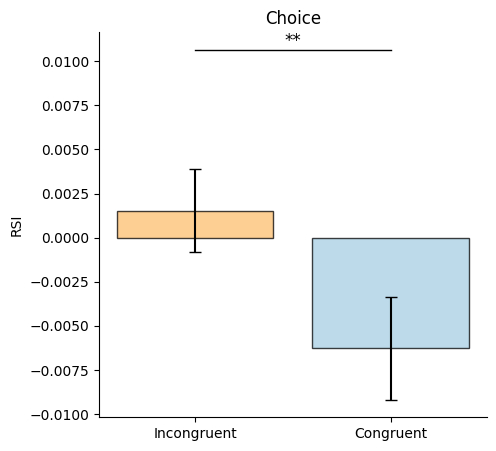

In [10]:
rsi_plots(final_dict=final_dict_choice, condition="Choice")
# plt.savefig("../reports/rsi_choice_alt_4bins.png", bbox_inches="tight", facecolor="white", dpi=300)

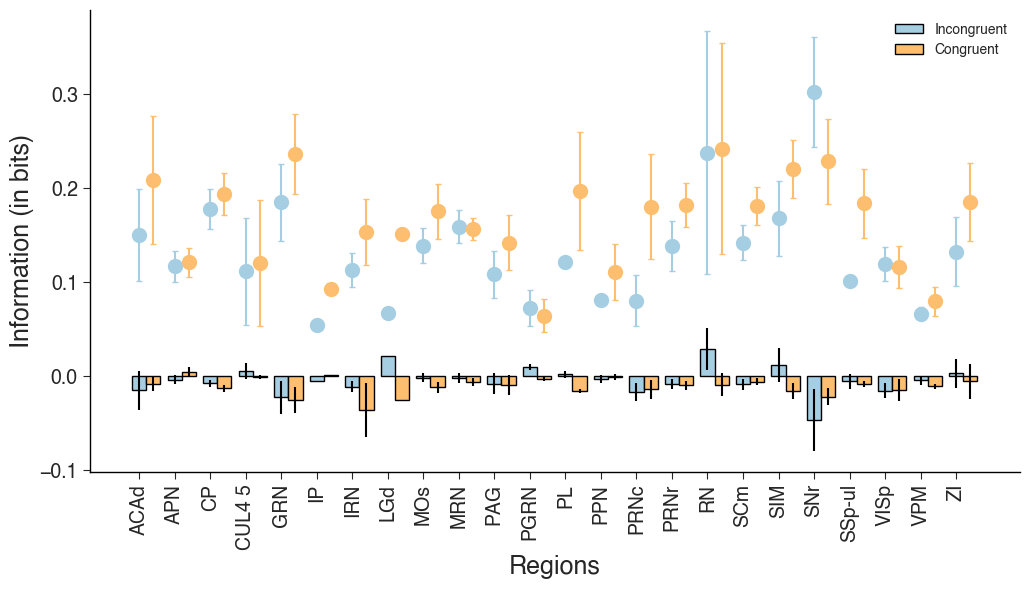

In [132]:
plot_region_wise_tvmi(final_dict=final_dict_choice)

In [100]:
# plot_counts(final_dict=final_dict_choice)

### plots for fraction of significant neurons


In [ ]:
# # for each region, we pick eids that have the region
# # we load the pseudosessions
# # we find the fraction of neurons (or number) with significant information?
# # for each significant neuron, we also store the MI value
# from ibl_info.selective_decomposition import filter_eids

# # we plot this for both choice and stim
# important_regions = [
#     "VISp",
#     "MOs",
#     "SSp-ul",
#     "ACAd",
#     "PL",
#     "CP",
#     "VPM",
#     "MG",
#     "LGd",
#     "ZI",
#     "SNr",
#     "MRN",
#     "SCm",
#     "PAG",
#     "APN",
#     "RN",
#     "PPN",
#     "PRNc",
#     "PRNr",
#     "GRN",
#     "IRN",
#     "PGRN",
#     "CUL4 5",
#     "SIM",
#     "IP",
# ]
# one = ONE(
#     base_url="https://openalyx.internationalbrainlab.org",
#     username="intbrainlab",
#     password="international",
# )
# unit_df = bwm_units(one)

# for region in tqdm(important_regions):
#     selective_eids = filter_eids(unit_df, region, significant_filter=False)
#     region_data = {}
#     for eid in selective_eids:
#         filename = f"./mi_significant_neurons_properpseudo_{eid}_choice.pkl"
#         with open(filename, "rb") as f:
#             mi_data = pkl.load(f)
#         try:
#             mi_data_region = mi_data[region]
#             ccids = mi_data_region["uuids"]
#             significant = mi_data_region["reject"]
#             mi_values = mi_data_region["mi_data"]

#             fraction = np.sum(significant) / significant.shape[0]
#             number = np.sum(significant)
#             mi_means = mi_values[significant]
#             temp = {}
#             temp["fraction"] = fraction
#             temp["number"] = number
#             temp["mi"] = mi_means
#             region_data[eid] = temp
#         except Exception as e:
#             print(e)
#     with open(f"./summary_stat_choice_{region}", "wb") as f:
#         pkl.dump(region_data, f)

In [15]:
plt.style.use("../figures.style")

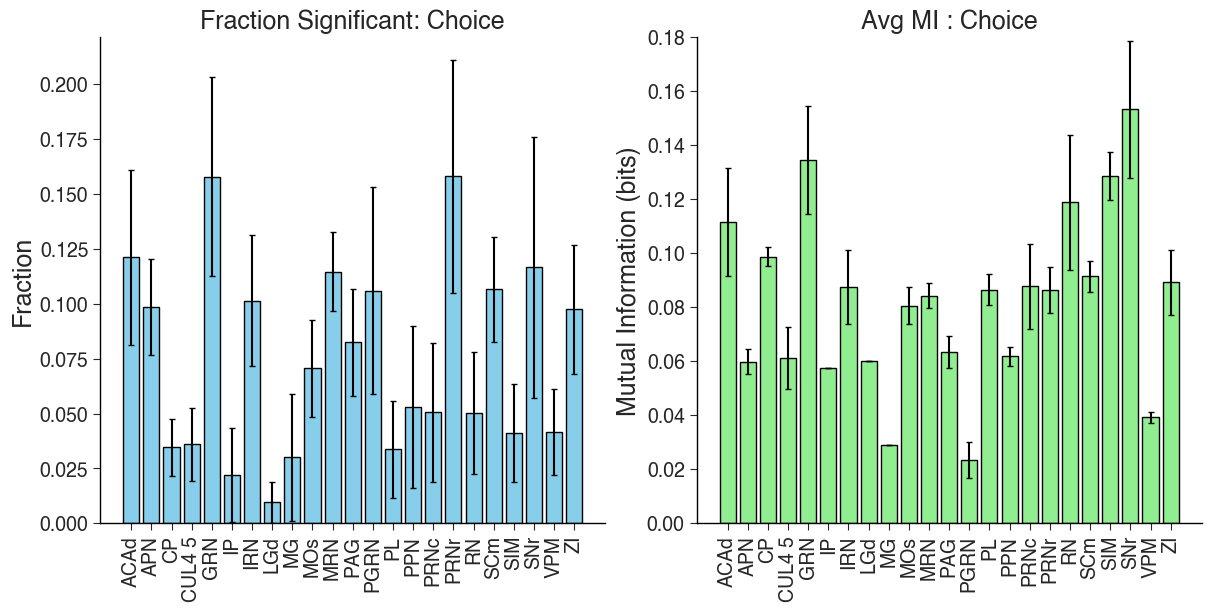

In [41]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 1. Identify the regions
# You can either define important_regions list manually or find the files
# important_regions = ["VISp", "MOs", ...]
file_pattern = "../data/generated/summary/choice_stat/*.pkl"
files = glob.glob(file_pattern)
important_regions = [f.split("summary_stat_choice_")[-1] for f in files]
important_regions = [f.rstrip(".pkl") for f in important_regions]

# Sort for consistent plotting order
important_regions.sort()

# Data containers
region_stats = {
    "names": [],
    "frac_mean": [],
    "frac_std": [],
    "num_mean": [],
    "num_std": [],
    "mi_mean": [],
    "mi_std": [],
}

for region in important_regions:
    filename = f"../data/generated/summary/choice_stat/summary_stat_choice_{region}.pkl"

    if not os.path.exists(filename):
        continue

    try:
        with open(filename, "rb") as f:
            region_data = pkl.load(f)

        # Lists to hold session-level averages for this region
        fractions = []
        counts = []
        avg_mis = []  # Average MI of significant neurons per session

        for eid, stats in region_data.items():
            # 1. Fraction
            fractions.append(stats["fraction"])

            # 2. Number
            counts.append(stats["number"])

            # 3. MI (Handle cases with 0 significant neurons to avoid NaN)
            mi_values = stats["mi"]
            if len(mi_values) > 0:
                avg_mis.append(np.mean(mi_values))
            else:
                avg_mis.append(np.nan)  # Or 0, depending on preference

        # Convert to arrays for calculation, ignoring NaNs for MI
        fractions = np.array(fractions)
        counts = np.array(counts)
        avg_mis = np.array(avg_mis)

        # Store Aggregated Stats (Mean across sessions)
        region_stats["names"].append(region)

        region_stats["frac_mean"].append(np.nanmean(fractions))
        region_stats["frac_std"].append(np.nanstd(fractions) / np.sqrt(len(fractions)))

        region_stats["num_mean"].append(np.nanmean(counts))
        region_stats["num_std"].append(np.nanstd(counts))

        region_stats["mi_mean"].append(np.nanmean(avg_mis))
        region_stats["mi_std"].append(np.nanstd(avg_mis) / np.sqrt(len(avg_mis)))

    except Exception as e:
        print(f"Error processing {region}: {e}")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Helper for plotting
x_pos = np.arange(len(region_stats["names"]))
bar_width = 0.6

# 1. Fraction Plot
axes[0].bar(
    x_pos,
    region_stats["frac_mean"],
    yerr=region_stats["frac_std"],
    align="center",
    capsize=2,
    color="skyblue",
    edgecolor="k",
)
axes[0].set_title("Fraction Significant: Choice")
axes[0].set_ylabel("Fraction")

# 3. MI Plot (Intensity of encoding)
axes[1].bar(
    x_pos,
    region_stats["mi_mean"],
    yerr=region_stats["mi_std"],
    align="center",
    capsize=2,
    color="lightgreen",
    edgecolor="k",
)
axes[1].set_title("Avg MI : Choice")
axes[1].set_ylabel("Mutual Information (bits)")

# Formatting all axes
for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(region_stats["names"], rotation=90)

axes[1].set_ylim(0, 0.18)

plt.savefig(
    "../reports/figures/choice_neurons_mi.png", dpi=300, bbox_inches="tight", facecolor="white"
)

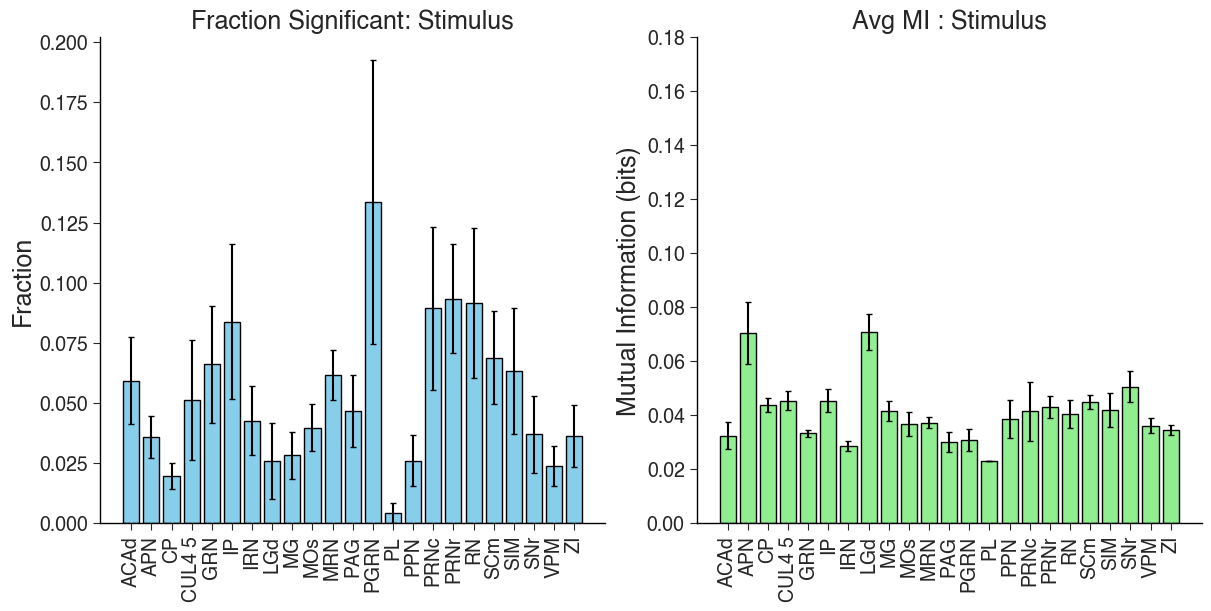

In [39]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# 1. Identify the regions
# You can either define important_regions list manually or find the files
# important_regions = ["VISp", "MOs", ...]
file_pattern = "../data/generated/summary/summary_stat_pseudold/*.pkl"
files = glob.glob(file_pattern)
important_regions = [f.split("summary_stat_stimulus_")[-1] for f in files]
important_regions = [f.rstrip(".pkl") for f in important_regions]

# Sort for consistent plotting order
important_regions.sort()

# Data containers
region_stats = {
    "names": [],
    "frac_mean": [],
    "frac_std": [],
    "num_mean": [],
    "num_std": [],
    "mi_mean": [],
    "mi_std": [],
}

for region in important_regions:
    filename = (
        f"../data/generated/summary/summary_stat_pseudold/summary_stat_stimulus_{region}.pkl"
    )

    if not os.path.exists(filename):
        continue

    try:
        with open(filename, "rb") as f:
            region_data = pkl.load(f)

        # Lists to hold session-level averages for this region
        fractions = []
        counts = []
        avg_mis = []  # Average MI of significant neurons per session

        for eid, stats in region_data.items():
            # 1. Fraction
            fractions.append(stats["fraction"])

            # 2. Number
            counts.append(stats["number"])

            # 3. MI (Handle cases with 0 significant neurons to avoid NaN)
            mi_values = stats["mi"]
            if len(mi_values) > 0:
                avg_mis.append(np.mean(mi_values))
            else:
                avg_mis.append(np.nan)  # Or 0, depending on preference

        # Convert to arrays for calculation, ignoring NaNs for MI
        fractions = np.array(fractions)
        counts = np.array(counts)
        avg_mis = np.array(avg_mis)

        # Store Aggregated Stats (Mean across sessions)
        region_stats["names"].append(region)

        region_stats["frac_mean"].append(np.nanmean(fractions))
        region_stats["frac_std"].append(np.nanstd(fractions) / np.sqrt(len(fractions)))

        region_stats["num_mean"].append(np.nanmean(counts))
        region_stats["num_std"].append(np.nanstd(counts))

        region_stats["mi_mean"].append(np.nanmean(avg_mis))
        region_stats["mi_std"].append(np.nanstd(avg_mis) / np.sqrt(len(avg_mis)))

    except Exception as e:
        print(f"Error processing {region}: {e}")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Helper for plotting
x_pos = np.arange(len(region_stats["names"]))
bar_width = 0.6

# 1. Fraction Plot
axes[0].bar(
    x_pos,
    region_stats["frac_mean"],
    yerr=region_stats["frac_std"],
    align="center",
    capsize=2,
    color="skyblue",
    edgecolor="k",
)
axes[0].set_title("Fraction Significant: Stimulus")
axes[0].set_ylabel("Fraction")

# 3. MI Plot (Intensity of encoding)
axes[1].bar(
    x_pos,
    region_stats["mi_mean"],
    yerr=region_stats["mi_std"],
    align="center",
    capsize=2,
    color="lightgreen",
    edgecolor="k",
)
axes[1].set_title("Avg MI : Stimulus")
axes[1].set_ylabel("Mutual Information (bits)")

# Formatting all axes
for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(region_stats["names"], rotation=90)

axes[1].set_ylim(0, 0.18)

plt.savefig(
    "../reports/figures/stimulus_neurons_mi.png", dpi=300, bbox_inches="tight", facecolor="white"
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


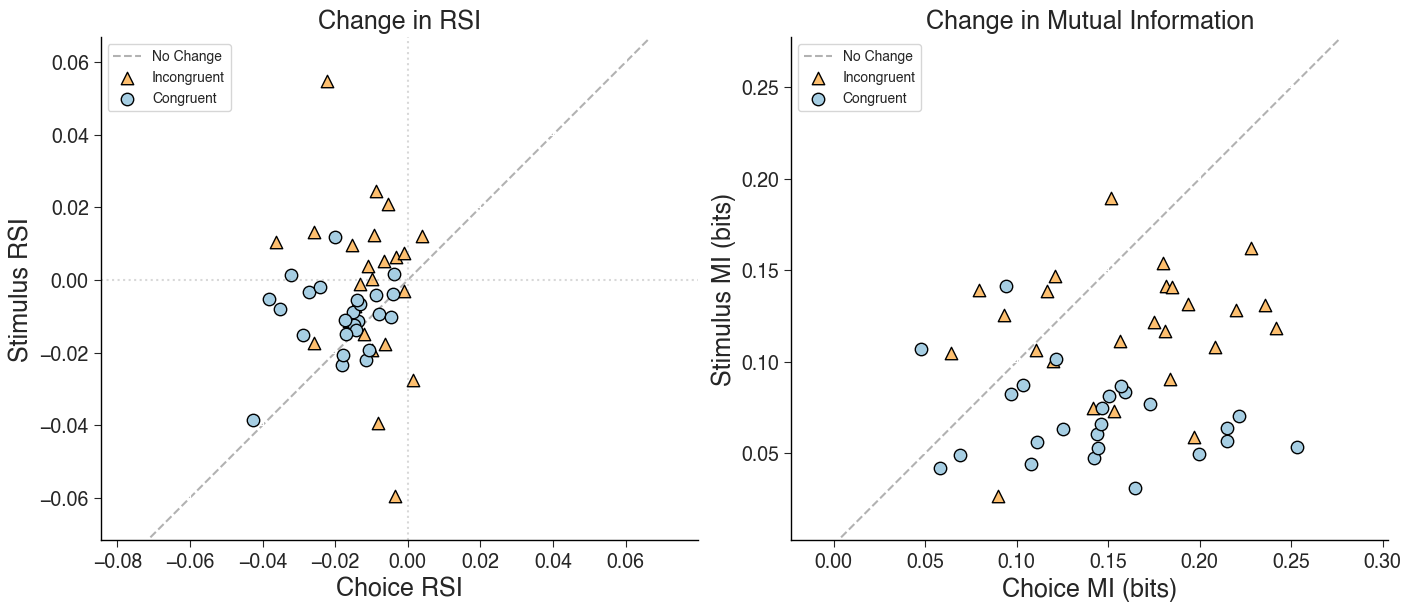

In [127]:
import matplotlib.pyplot as plt
import numpy as np


def plot_dynamics_autoscale_swapped(stim_dict, choice_dict):
    """
    Plots the transition between epochs grouped by congruency.
    X-axis: Choice Epoch Value
    Y-axis: Stimulus Epoch Value
    """
    # Adjust these indices based on your actual data structure
    IDX_INCONG = 1
    IDX_CONG = 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    panels = [
        {"key": "region_means_rsi", "title": "Change in RSI", "ax": axes[0], "label": "RSI"},
        {
            "key": "region_means_tvmi",
            "title": "Change in Mutual Information",
            "ax": axes[1],
            "label": "MI (bits)",
        },
    ]

    for panel in panels:
        ax = panel["ax"]
        key = panel["key"]

        # --- EXTRACT DATA (SWAPPED AXES) ---
        # X-AXIS = CHOICE EPOCH
        incong_x = choice_dict[key][:, IDX_INCONG]
        cong_x = choice_dict[key][:, IDX_CONG]

        # Y-AXIS = STIMULUS EPOCH
        incong_y = stim_dict[key][:, IDX_INCONG]
        cong_y = stim_dict[key][:, IDX_CONG]

        # --- DYNAMIC LIMITS ---
        # Find min and max across ALL data to keep the plot square and fully visible
        all_data = np.concatenate([incong_x, incong_y, cong_x, cong_y])
        d_min, d_max = np.nanmin(all_data), np.nanmax(all_data)

        # Add 10% padding
        pad = (d_max - d_min) * 0.1
        if pad == 0:
            pad = 0.01
        lims = (d_min - pad, d_max + pad)
        color = ["#FDBF6F", "#A6CEE3"]

        # --- PLOTTING ---
        # 1. Identity Line (y=x)
        ax.plot(lims, lims, ls="--", c="black", alpha=0.3, zorder=0, label="No Change")

        # 2. Zero lines (for RSI only)
        if "rsi" in key.lower():
            ax.axvline(0, ls=":", c="gray", alpha=0.3)
            ax.axhline(0, ls=":", c="gray", alpha=0.3)

        # 3. Scatter Points
        # Incongruent (Red Triangles)
        ax.scatter(
            incong_x,
            incong_y,
            c=color[0],
            s=80,
            edgecolors="k",
            marker="^",
            label="Incongruent",
        )

        # Congruent (Blue Circles)
        ax.scatter(
            cong_x,
            cong_y,
            c=color[1],
            s=80,
            edgecolors="k",
            marker="o",
            label="Congruent",
        )

        # 4. Styling
        ax.set_aspect("equal", adjustable="datalim")
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel(f"Choice {panel['label']}", fontweight="bold")
        ax.set_ylabel(f"Stimulus {panel['label']}", fontweight="bold")
        ax.set_title(panel["title"])
        ax.legend(loc="upper left", frameon=True)

    return fig


# Run the function
fig = plot_dynamics_autoscale_swapped(final_dict_stim, final_dict_choice)
plt.show()